# 📊 Model Comparison

## Objective

This notebook evaluates the best trained model and visualizes its performance.

### Features

- Load saved model
- Load leaderboard
- Confusion Matrix
- ROC Curve
- Precision-Recall Curve
- Classification Report
- Feature Importance
- Regression Metrics (if regression)

In [1]:
# ==========================================================
# Import Libraries
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import *

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
# ==========================================================
# Load Dataset
# ==========================================================

df = pd.read_csv("../data/processed/engineered_dataset.csv")

display(df.head())

print(df.shape)

,0,1,2,3,4,5,6,7,8,9,...,24,25,26,27,28,29,30,31,32,churn
0,0.252523,-0.966389,0.712562,0.700230,1.172672,-0.475563,-0.133784,-0.130690,-0.135197,-0.126553,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
1,-0.110551,-0.460965,-0.330877,1.705519,1.172672,-0.278289,-0.133200,-0.136127,-0.138771,-0.126228,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0
2,0.036146,-0.067858,-0.330877,-1.085387,-0.341489,-0.268692,-0.104552,-0.115572,-0.114066,-0.092763,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0
3,1.011677,2.346943,-0.330877,0.899413,-1.855650,-0.789069,0.149746,0.148655,0.152553,0.127798,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,-1.555510,-0.011700,-0.330877,-1.832910,-0.341489,-0.040494,-0.021270,-0.024014,-0.024500,-0.061926,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0


(36994, 34)


In [3]:
# ==========================================================
# Detect Target
# ==========================================================

possible_targets = [

    "target",
    "label",
    "class",
    "output",
    "prediction",
    "churn",
    "price"

]

target = None

for col in df.columns:

    if col.lower() in possible_targets:

        target = col

        break

if target is None:

    target = df.columns[-1]

print(target)

churn


In [4]:
X = df.drop(columns=[target])

y = df[target]

In [5]:
problem = "classification" if y.nunique() <= 20 else "regression"

print(problem)

classification


In [6]:
from sklearn.model_selection import train_test_split

if problem == "classification":

    X_train, X_test, y_train, y_test = train_test_split(

        X,

        y,

        test_size=0.2,

        random_state=42,

        stratify=y

    )

else:

    X_train, X_test, y_train, y_test = train_test_split(

        X,

        y,

        test_size=0.2,

        random_state=42

    )

In [8]:
# ==========================================================
# Load Best Model
# ==========================================================

model = joblib.load("../artifacts/best_model.pkl")

print(model)

ExtraTreesClassifier(random_state=42)


In [9]:
y_pred = model.predict(X_test)

if problem == "classification":

    y_prob = model.predict_proba(X_test)[:,1]

In [11]:
leaderboard = pd.read_csv("../artifacts/model_leaderboard.csv")

leaderboard

,Model,Accuracy,Precision,Recall,F1 Score,CV Mean,CV Std,Training Time
0,Extra Trees,0.937965,0.947020,0.927818,0.937321,0.896232,0.000443,12.898737
1,CatBoost,0.901743,0.926766,0.872398,0.898761,0.889204,0.001044,20.822012
2,XGBoost,0.900257,0.917160,0.879968,0.898179,0.891468,0.001078,1.081359
3,LightGBM,0.890255,0.912311,0.863477,0.887222,0.881399,0.002564,1.161272
4,Random Forest,0.883227,0.881767,0.885104,0.883432,0.857239,0.002124,10.995892
5,Hist Gradient Boosting,0.881741,0.900681,0.858070,0.878859,0.877040,0.000300,2.135445
6,Gradient Boosting,0.854710,0.873789,0.829143,0.850881,0.851292,0.000907,21.575911
7,AdaBoost,0.793891,0.813799,0.762098,0.787100,0.802095,0.002068,4.362210
8,Decision Tree,0.791053,0.788993,0.794539,0.791756,0.772664,0.003304,0.973475
9,Logistic Regression,0.693878,0.709772,0.655853,0.681748,0.699679,0.008795,0.546299


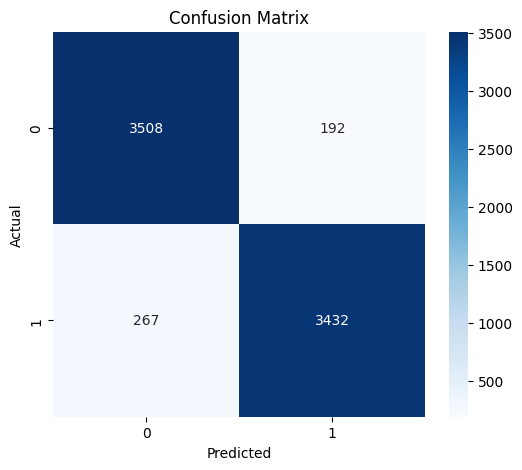

In [12]:
if problem=="classification":

    cm = confusion_matrix(y_test,y_pred)

    plt.figure(figsize=(6,5))

    sns.heatmap(

        cm,

        annot=True,

        fmt="d",

        cmap="Blues"

    )

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.title("Confusion Matrix")

    plt.show()

In [13]:
if problem=="classification":

    report = classification_report(

        y_test,

        y_pred,

        output_dict=True

    )

    report = pd.DataFrame(report).transpose()

    display(report)

,precision,recall,f1-score,support
0,0.929272,0.948108,0.938595,3700.000000
1,0.947020,0.927818,0.937321,3699.000000
accuracy,0.937965,0.937965,0.937965,0.937965
macro avg,0.938146,0.937963,0.937958,7399.000000
weighted avg,0.938144,0.937965,0.937958,7399.000000


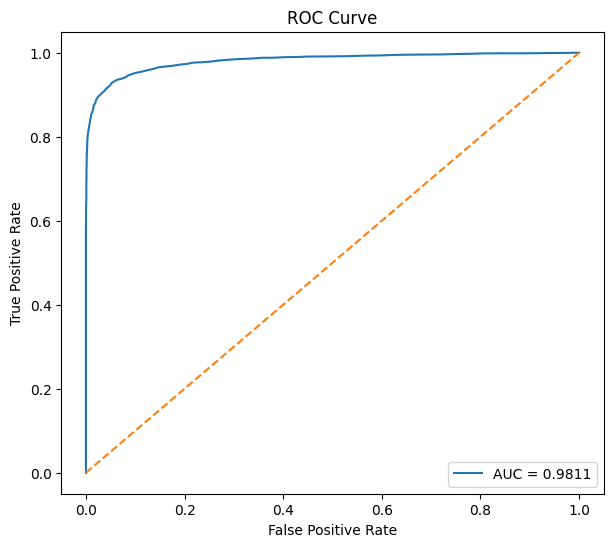

In [14]:
if problem=="classification":

    fpr,tpr,_ = roc_curve(

        y_test,

        y_prob

    )

    auc = roc_auc_score(

        y_test,

        y_prob

    )

    plt.figure(figsize=(7,6))

    plt.plot(

        fpr,

        tpr,

        label=f"AUC = {auc:.4f}"

    )

    plt.plot([0,1],[0,1],"--")

    plt.xlabel("False Positive Rate")

    plt.ylabel("True Positive Rate")

    plt.title("ROC Curve")

    plt.legend()

    plt.show()

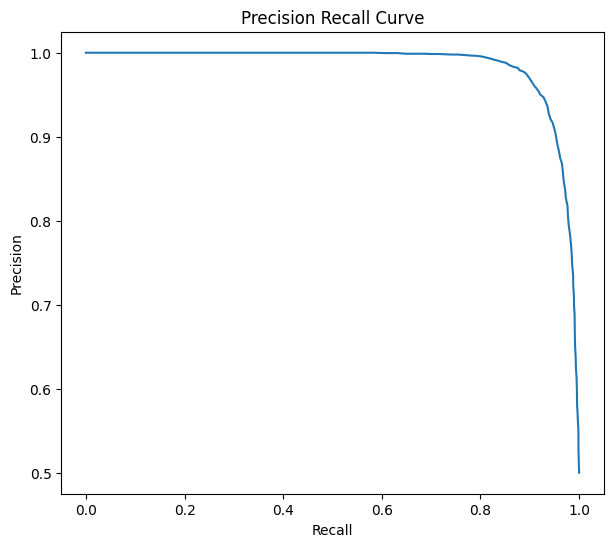

In [15]:
if problem=="classification":

    precision,recall,_ = precision_recall_curve(

        y_test,

        y_prob

    )

    plt.figure(figsize=(7,6))

    plt.plot(

        recall,

        precision

    )

    plt.xlabel("Recall")

    plt.ylabel("Precision")

    plt.title("Precision Recall Curve")

    plt.show()

In [16]:
if problem=="classification":

    metrics = pd.DataFrame({

        "Metric":[

            "Accuracy",

            "Precision",

            "Recall",

            "F1 Score",

            "ROC AUC"

        ],

        "Score":[

            accuracy_score(y_test,y_pred),

            precision_score(y_test,y_pred),

            recall_score(y_test,y_pred),

            f1_score(y_test,y_pred),

            roc_auc_score(y_test,y_prob)

        ]

    })

else:

    metrics = pd.DataFrame({

        "Metric":[

            "RMSE",

            "MAE",

            "R2"

        ],

        "Score":[

            np.sqrt(mean_squared_error(y_test,y_pred)),

            mean_absolute_error(y_test,y_pred),

            r2_score(y_test,y_pred)

        ]

    })

display(metrics)

,Metric,Score
0,Accuracy,0.937965
1,Precision,0.947020
2,Recall,0.927818
3,F1 Score,0.937321
4,ROC AUC,0.981059


,Feature,Importance
12,12,0.080811
6,6,0.073626
13,13,0.061280
17,17,0.050349
14,14,0.046225
18,18,0.044738
1,1,0.042643
3,3,0.042519
5,5,0.041121
15,15,0.039855


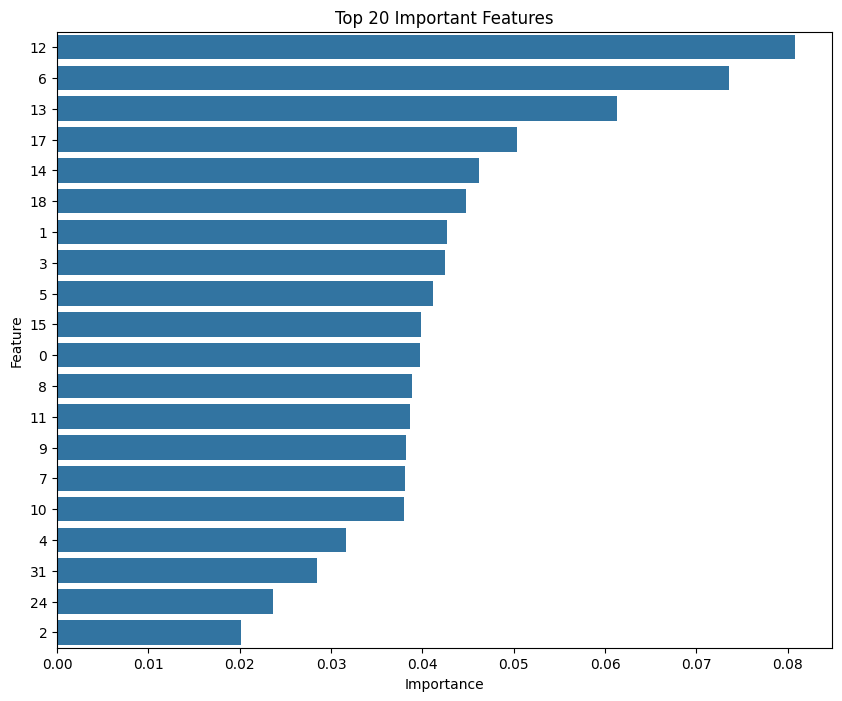

In [17]:
if hasattr(model,"feature_importances_"):

    importance = pd.DataFrame({

        "Feature":X.columns,

        "Importance":model.feature_importances_

    })

    importance = importance.sort_values(

        by="Importance",

        ascending=False

    )

    display(importance.head(20))

    plt.figure(figsize=(10,8))

    sns.barplot(

        data=importance.head(20),

        x="Importance",

        y="Feature"

    )

    plt.title("Top 20 Important Features")

    plt.show()

In [18]:
leaderboard.sort_values(

    by="Accuracy" if problem=="classification" else "R2 Score",

    ascending=False

)

,Model,Accuracy,Precision,Recall,F1 Score,CV Mean,CV Std,Training Time
0,Extra Trees,0.937965,0.947020,0.927818,0.937321,0.896232,0.000443,12.898737
1,CatBoost,0.901743,0.926766,0.872398,0.898761,0.889204,0.001044,20.822012
2,XGBoost,0.900257,0.917160,0.879968,0.898179,0.891468,0.001078,1.081359
3,LightGBM,0.890255,0.912311,0.863477,0.887222,0.881399,0.002564,1.161272
4,Random Forest,0.883227,0.881767,0.885104,0.883432,0.857239,0.002124,10.995892
5,Hist Gradient Boosting,0.881741,0.900681,0.858070,0.878859,0.877040,0.000300,2.135445
6,Gradient Boosting,0.854710,0.873789,0.829143,0.850881,0.851292,0.000907,21.575911
7,AdaBoost,0.793891,0.813799,0.762098,0.787100,0.802095,0.002068,4.362210
8,Decision Tree,0.791053,0.788993,0.794539,0.791756,0.772664,0.003304,0.973475
9,Logistic Regression,0.693878,0.709772,0.655853,0.681748,0.699679,0.008795,0.546299


# 📌 Conclusion

This notebook provides a complete evaluation of the trained model using:

- Leaderboard comparison
- Confusion Matrix
- Classification Report
- ROC Curve
- Precision–Recall Curve
- Feature Importance
- Final Metrics Summary

These analyses help identify the best-performing model and understand its predictive behavior before deployment.